# MFCC CNN: Compacted architecture for hls4ml + QAT

## Changes related to original architecture 

For using `Strategy='Latency'` with `ReuseFactor=1` (min latency in FPGA),
each layer must have ≤ 4096 parameters. The original model **exceeded this limit**:

| Layer (original) | Elements | Status |
|---|---|---|
| `Conv2D(32)` | 3×3×2×32 = 576 | ✓ |
| `Conv2D(64)` | 3×3×32×64 = **18,432** | ✗ |
| `Dense(128)` | 22,400×128 = **2,867,200** | ✗ |

The new compact architecture (3 Conv blocks + small Dense) respects the limit in all layers.



In [ ]:
import os, json, re, warnings

if 'CUDA_VISIBLE_DEVICES' not in os.environ:
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # CPU only

_vitis_hls = os.environ.get('XILINX_HLS', '')

if _vitis_hls and _vitis_hls not in os.environ.get('PATH', ''):
    os.environ['PATH'] = _vitis_hls + '/bin:' + os.environ['PATH']
elif not _vitis_hls:
    import glob as _glob
    _candidates = sorted(_glob.glob('/tools/Xilinx/Vitis_HLS/*/bin/vitis_hls'))
    if _candidates:
        _detected = os.path.dirname(os.path.dirname(_candidates[-1]))
        os.environ['XILINX_HLS']  = _detected
        os.environ['XILINX_VITIS'] = _detected.replace('Vitis_HLS', 'Vitis')
        os.environ['PATH'] = _detected + '/bin:' + os.environ['PATH']
        print(f'Vitis HLS detected: {_detected}')
    else:
        print('WARNING: Vitis HLS not found. Synthesis will not be available.')

import tensorflow as tf
import pickle
import numpy as np
import matplotlib.pyplot as plt


from qkeras import QConv2D, QDense, QActivation, quantized_bits, quantized_relu
from qkeras.utils import _add_supported_quantized_objects

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer, BatchNormalization, MaxPooling2D,
    Flatten, Dropout, Dense, Activation, Conv2D
)
from tensorflow.keras.optimizers import Adam
import hls4ml

RANDOM_SEED = 55
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')

# Hardware target
FPGA_PART    = 'xck26-sfvc784-2LV-c'
CLOCK_PERIOD = 5          # ns → 200 MHz
TARGET_SNR   = '76dB'
HLS_BASE_DIR = './hls4ml_output_compact'

# Training hyperparameters
MAX_EPOCHS    = 150
LEARNING_RATE = 1e-3      # LR for base float model
PATIENCE      = 20

QKERAS_CO = {}
_add_supported_quantized_objects(QKERAS_CO)

# Show active device
gpus = tf.config.list_physical_devices('GPU')
print('Training device:', 'GPU' if gpus else 'CPU')
print('TF:', tf.__version__)
print('hls4ml:', hls4ml.__version__)


Dispositivo de entrenamiento: CPU
TF: 2.14.0
hls4ml: 1.2.0


## Cargar parámetros del dataset

In [ ]:
DATASETS_PATH = 'MFCC_datasets'
METADATA_PATH = os.path.join(DATASETS_PATH, 'metadata.json')

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, 'r') as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata['MFCC_input_shape'])
    NUM_CLASSES      = metadata['num_classes']
    N_MFCC           = metadata.get('N_MFCC', 20)
    MFCC_FRAMES      = metadata.get('MFCC_FRAMES')
    HOP_LENGTH       = metadata.get('HOP_LENGTH', 2250)
    N_FFT            = metadata.get('N_FFT', 2048)
    SAMPLING_FREQ    = metadata.get('SAMPLING_FREQ', 48000)
    batch_size       = metadata.get('batch_size', 32)
    subfolders       = metadata.get('subfolders', [])
    unique_labels    = metadata.get('labels', [])
    print('Metadata loaded from metadata.json')
else:
    raise FileNotFoundError(
        'metadata.json not found in MFCC_datasets/ -- '
        'run MFCC_dataset_generation.ipynb first.'
    )

# Verify dataset BRAM-Opt v2 (hop=2250, frames=64)
assert MFCC_FRAMES == 64 and HOP_LENGTH == 2250, (
    f'\n[ERROR] Dataset incompatible with BRAM-Opt v2 architecture:\n'
    f'  MFCC_FRAMES = {MFCC_FRAMES}  (expected: 64)\n'
    f'  HOP_LENGTH  = {HOP_LENGTH}  (expected: 2250)\n'
    'Solution: run MFCC_dataset_generation.ipynb with hop_length=2250.'
)

print(f'  MFCC input shape : {MFCC_input_shape}')
print(f'  Num classes      : {NUM_CLASSES}')
print(f'  N_MFCC           : {N_MFCC}')
print(f'  MFCC_FRAMES      : {MFCC_FRAMES}  '
      f'(hop={HOP_LENGTH} => {HOP_LENGTH/SAMPLING_FREQ*1000:.1f} ms/frame)')
print(f'  Sampling freq    : {SAMPLING_FREQ} Hz')
print(f'  Classes          : {subfolders}')
print('\n[OK] Dataset BRAM-Opt v2 verified (MFCC_FRAMES=64, hop_length=2250)')

# Load datasets
SPEC_PATH = os.path.join(DATASETS_PATH, 'element_spec.pkl')
with open(SPEC_PATH, 'rb') as f:
    specs = pickle.load(f)

MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'train_batches'),
    element_spec=specs['train']
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, 'validation_batches'),
    element_spec=specs['validation']
).prefetch(tf.data.AUTOTUNE)

for bX, by in MFCC_dataset_train_batches.take(1):
    print(f'Train batch: X={bX.shape}, y={by.shape}')
print('Datasets cargados.')


Metadata cargada desde metadata.json
  MFCC input shape : (20, 64, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 64  (hop=2250 => 46.9 ms/frame)
  Sampling freq    : 48000 Hz
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']

[OK] Dataset BRAM-Opt v2 verificado (MFCC_FRAMES=64, hop_length=2250)
Train batch: X=(32, 20, 64, 2), y=(32,)
Datasets cargados.


## BRAM-Opt v2 Architecture -- input `(20, 64, 2)`

Input generated by `MFCC_dataset_generation.ipynb`
with `hop_length=2250`, `MFCC_FRAMES=64`.

```
Input  (20, 64, 2)
  +- Conv2D(8, 3x3, same)   3x3x2x8 =  144 params OK  ->  (20, 64, 8)
  +- BN + ReLU
  +- MaxPool(2, 2)                                    ->  (10, 32, 8)
  +- Conv2D(8, 3x3, same)   3x3x8x8 =  576 params OK  ->  (10, 32, 8)
  +- BN + ReLU
  +- MaxPool(2, 4)                                    ->  ( 5,  8, 8)
  +- Conv2D(8, 3x3, same)   3x3x8x8 =  576 params OK  ->  ( 5,  8, 8)
  +- BN + ReLU
  +- MaxPool(5, 4)                                    ->  ( 1,  2, 8)
  +- Flatten                                          ->  16
  +- Dense(16)               16x16  =  256 params OK
  +- Dense(NUM_CLASSES)      16x10  =  160 params OK
```

### DSPs (with ReuseFactor)

| Capa | MACs | RF | DSPs |
|---|---|---|---|
| conv1 | 144 | 1 | 144 |
| conv2 | 576 | 4 | 144 |
| conv3 | 576 | 4 | 144 |
| dense1 | 256 | 1 | 256 |
| output | 160 | 1 | 160 |
| **Total** | | | **848 (68 %)** OK |

### BRAM_18K (io_stream)

| Input | FIFO depth | BRAM_18K est. | % KV260 |
|---|---|---|---|
| Original (20x282) | 5640 | ~681 | 236 % FAIL |
| **BRAM-Opt (20x64)** | **1280** | **~120** | **42 %** OK |


In [ ]:
# --- Model definition -- BRAM-Opt v2 -----------------------------------

def build_compact_float_model(input_shape, n_classes):
    """
    CNN BRAM-Opt v2 -- all layers <= 576 parameters.
    Designed for input shape (20, 64, 2).

    Spatial reduction MFCC (20, 64):
      MaxPool(2, 2)  ->  (10, 32)
      MaxPool(2, 4)  ->  ( 5,  8)
      MaxPool(5, 4)  ->  ( 1,  2)  ->  Flatten: 1x2x8 = 16
    """
    model = Sequential([
        InputLayer(input_shape),
        # -- Block 1: (20, 64, 2) -> (10, 32, 8) ---------------------------
        Conv2D(8, (3, 3), padding='same', name='conv1'),   # 144 params
        BatchNormalization(name='bn1'),
        Activation('relu', name='act1'),
        MaxPooling2D((2, 2), name='pool1'),
        # -- Block 2: (10, 32, 8) -> (5, 8, 8) -----------------------------
        Conv2D(8, (3, 3), padding='same', name='conv2'),   # 576 params
        BatchNormalization(name='bn2'),
        Activation('relu', name='act2'),
        MaxPooling2D((2, 4), name='pool2'),
        # -- Block 3: (5, 8, 8) -> (1, 2, 8) -------------------------------
        Conv2D(8, (3, 3), padding='same', name='conv3'),   # 576 params
        BatchNormalization(name='bn3'),
        Activation('relu', name='act3'),
        MaxPooling2D((5, 4), name='pool3'),
        # -- Classifier: 16 -> 16 -> n_classes -----------------------------
        Flatten(name='flatten'),
        Dense(16, name='dense1'),                          # 256 params
        Activation('relu', name='act4'),
        Dropout(0.3, name='dropout'),
        Dense(n_classes, name='output'),                   # 160 params (N=10)
        Activation('softmax', name='softmax'),
    ], name='Compact_CNN_Float_v2')
    return model


def build_compact_qat_model(input_shape, n_classes, bits,
                             int_bits_kernel, int_bits_activation):
    """
    QAT version of the BRAM-Opt v2 model.

    int_bits separated for kernel and activations: in 4-bit the
    activations need more range to avoid clipping of BN+ReLU.
    """
    kq = quantized_bits(bits, int_bits_kernel, keep_negative=1, alpha=1)
    aq = quantized_relu(bits, int_bits_activation)

    model = Sequential([
        InputLayer(input_shape),
        # -- Block 1 --------------------------------------------------------
        QConv2D(8, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv1'),
        BatchNormalization(name='bn1'),
        QActivation(activation=aq, name='act1'),
        MaxPooling2D((2, 2), name='pool1'),
        # -- Block 2 --------------------------------------------------------
        QConv2D(8, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv2'),
        BatchNormalization(name='bn2'),
        QActivation(activation=aq, name='act2'),
        MaxPooling2D((2, 4), name='pool2'),
        # -- Block 3 --------------------------------------------------------
        QConv2D(8, (3, 3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv3'),
        BatchNormalization(name='bn3'),
        QActivation(activation=aq, name='act3'),
        MaxPooling2D((5, 4), name='pool3'),
        # -- Classifier ----------------------------------------------------
        Flatten(name='flatten'),
        QDense(16, kernel_quantizer=kq, bias_quantizer=kq, name='dense1'),
        QActivation(activation=aq, name='act4'),
        Dropout(0.3, name='dropout'),
        QDense(n_classes, kernel_quantizer=kq, bias_quantizer=kq,
               name='output'),
        Activation('softmax', name='softmax'),
    ], name=f'Compact_CNN_QAT_{bits}bit_v2')
    return model


# --- Utilities -------------------------------------------------------------

def verify_layer_sizes(model, max_elements=4096):
    """Verifies that each layer's weights have <= max_elements elements."""
    print(f'\nVerifying layer sizes (limit: {max_elements})')
    print('-' * 68)
    all_ok = True
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        w = weights[0]
        n = int(np.prod(w.shape))
        ok = n <= max_elements
        status = 'OK' if ok else 'EXCEDE'
        if not ok:
            all_ok = False
        print(f'  {status:10s} {layer.name:20s}: {n:7d} elements | shape {w.shape}')
    print('-' * 68)
    if all_ok:
        print('[OK] All layers <= 4096')
    else:
        print('[WARN] Some layers exceed 4096 -> use Strategy=Resource with high ReuseFactor')
    return all_ok


def transfer_float_weights(float_model, qat_model):
    """Transfers weights from the float model to the QAT model (same architecture)."""
    float_wl = [l for l in float_model.layers if l.get_weights()]
    qat_wl   = [l for l in qat_model.layers  if l.get_weights()]
    n_ok = 0
    for fl, ql in zip(float_wl, qat_wl):
        try:
            ql.set_weights(fl.get_weights())
            n_ok += 1
        except ValueError:
            print(f'  Omitted: {fl.name} -> {ql.name} (incompatible shapes)')
    print(f'  Weights transferred: {n_ok} layers.')


def save_history(history_obj, filepath):
    """Saves Keras training history to JSON (cumulative)."""
    new_hist = {k: [float(v) for v in vals]
                for k, vals in history_obj.history.items()}
    if os.path.exists(filepath):
        with open(filepath) as f:
            old_hist = json.load(f)
        for key, vals in new_hist.items():
            old_hist.setdefault(key, []).extend(vals)
        combined = old_hist
    else:
        combined = new_hist
    with open(filepath, 'w') as f:
        json.dump(combined, f, indent=2)
    print(f'History saved -> {filepath}')


def load_history(filepath):
    with open(filepath) as f:
        return json.load(f)


def plot_training_history(history_dict, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_dict.get('accuracy',     []), label='Train')
    axes[0].plot(history_dict.get('val_accuracy', []), label='Validation')
    axes[0].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1], title='Accuracy')
    axes[0].legend()
    for key in ['loss', 'val_loss']:
        vals = history_dict.get(key, [])
        if not vals:
            continue
        mx = max(vals) or 1.0
        axes[1].plot([v / mx for v in vals], label=key)
    axes[1].set(xlabel='Epoch', ylabel='Loss (Normalized)',
                title='Loss (Normalized)', ylim=[0, 1])
    axes[1].legend()
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print('Functions defined.')


Funciones definidas correctamente.


## Train the compact float model

If a saved checkpoint exists it is loaded directly.  
If not, the model is trained from scratch with:
- Adam with `LR=1e-3` + `ReduceLROnPlateau`
- `EarlyStopping(patience=20)`
- `ModelCheckpoint` (saves the best model by `val_accuracy`)

Entrenando modelo float compacto desde cero...
Model: "Compact_CNN_Float_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 20, 64, 8)         152       
                                                                 
 bn1 (BatchNormalization)    (None, 20, 64, 8)         32        
                                                                 
 act1 (Activation)           (None, 20, 64, 8)         0         
                                                                 
 pool1 (MaxPooling2D)        (None, 10, 32, 8)         0         
                                                                 
 conv2 (Conv2D)              (None, 10, 32, 8)         584       
                                                                 
 bn2 (BatchNormalization)    (None, 10, 32, 8)         32        
                                                                 

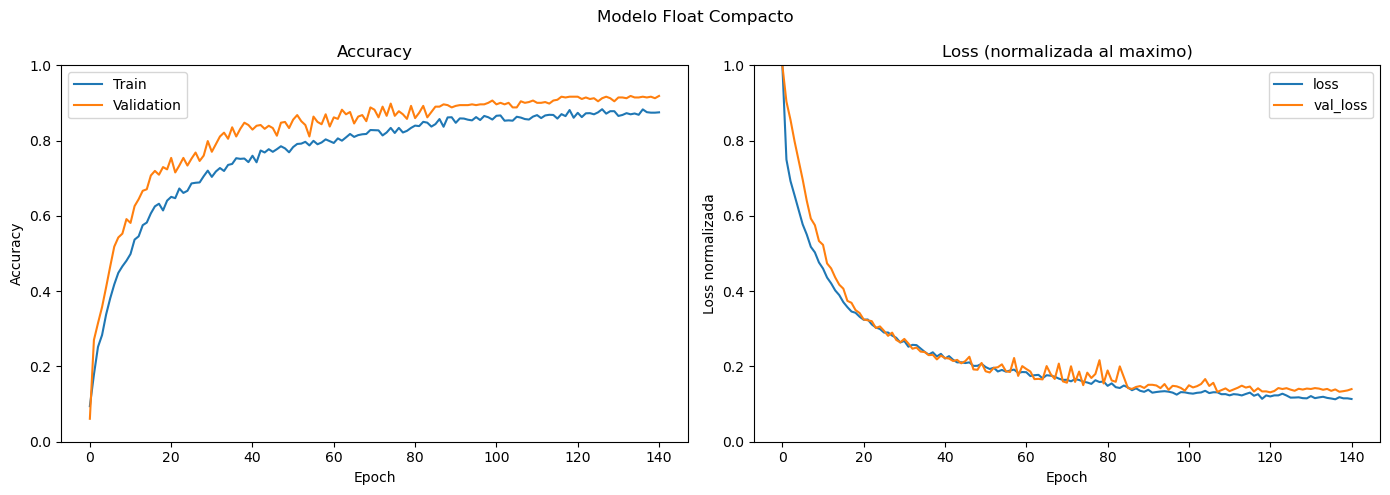


Evaluación modelo float compacto:
16/16 [==============================] - 0s 7ms/step - loss: 0.3138 - accuracy: 0.9167
  Val Loss: 0.3138 | Val Accuracy: 0.9167


In [ ]:
COMPACT_CKPT_DIR  = './ckpt_compact_float'
COMPACT_CKPT_PATH = f'{COMPACT_CKPT_DIR}/compact_float_best.h5'
COMPACT_HIST_PATH = f'{COMPACT_CKPT_DIR}/compact_float_history.json'
os.makedirs(COMPACT_CKPT_DIR, exist_ok=True)

if os.path.exists(COMPACT_CKPT_PATH):
    print(f'Loading model from: {COMPACT_CKPT_PATH}')
    model_compact_float = tf.keras.models.load_model(COMPACT_CKPT_PATH)
    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
else:
    print('Training model from scratch...')
    model_compact_float = build_compact_float_model(MFCC_input_shape, NUM_CLASSES)
    model_compact_float.summary()

    verify_layer_sizes(model_compact_float)

    model_compact_float.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks_float = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            verbose=1,
            min_lr=1e-6
        )
    ]

    history_float = model_compact_float.fit(
        MFCC_dataset_train_batches,
        epochs=MAX_EPOCHS,
        validation_data=MFCC_dataset_validation_batches,
        callbacks=callbacks_float
    )

    # Save best model manually in H5 format (without passing 'options')
    model_compact_float.save(COMPACT_CKPT_PATH, save_format='h5')
    print(f'Model saved → {COMPACT_CKPT_PATH}')
    save_history(history_float, COMPACT_HIST_PATH)

# Show history if exists
if os.path.exists(COMPACT_HIST_PATH):
    plot_training_history(
        load_history(COMPACT_HIST_PATH),
        title='Compact Float Model'
    )

print('\nFloat model evaluation:')
loss_f, acc_f = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=1
)
print(f'  Val Loss: {loss_f:.4f} | Val Accuracy: {acc_f:.4f}')


## Quantization-Aware Training (QAT)

```
bits | int_bits_kernel | int_bits_act | épocas | LR corregido
-----+-----------------+--------------+--------+-------------
 16  |        6        |      6       |   30   |    1e-5
  8  |        4        |      4       |   40   |    1e-4  
  4  |        2        |      3       |   60   |    5e-4  
```

For 4-bit, `int_bits_activation=3` allows activations of 7.5
instead of 3.75, reducing BN+ReLU clipping.


  QAT 16-bit  (int_k=6, int_act=6, LR=1e-05)
  Modelo pre-entrenado encontrado: ./ckpt_compact_QAT_16bit_76dB/compact_QAT_16bit_best.h5


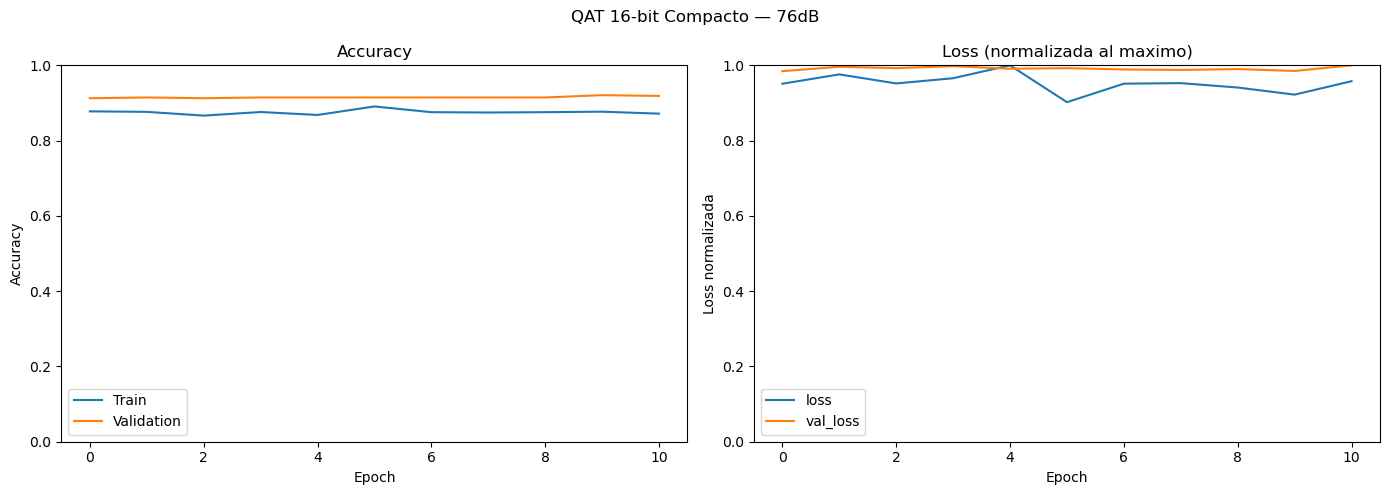


  QAT 8-bit  (int_k=4, int_act=4, LR=0.0001)
  Modelo pre-entrenado encontrado: ./ckpt_compact_QAT_8bit_76dB/compact_QAT_8bit_best.h5


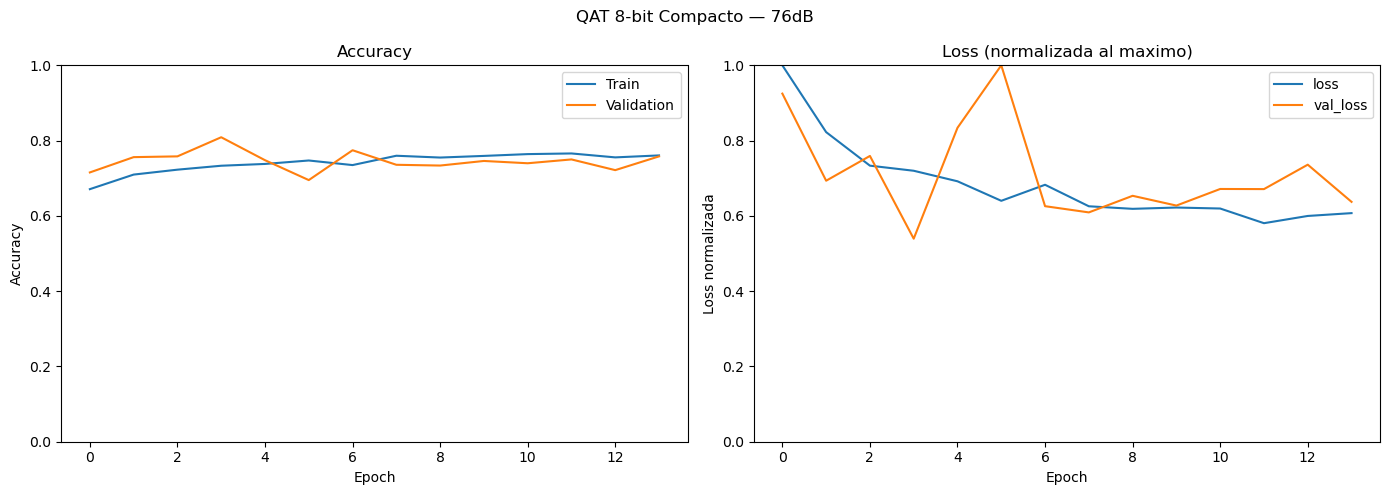


  QAT 4-bit  (int_k=2, int_act=3, LR=0.0005)
  Construyendo modelo QAT y transfiriendo pesos float...
  Pesos transferidos: 8 capas.
Epoch 1/500
72/72 [==============================] - 4s 26ms/step - loss: 6.4400 - accuracy: 0.1232 - val_loss: 8.4833 - val_accuracy: 0.1179
Epoch 2/500
72/72 [==============================] - 1s 20ms/step - loss: 3.8407 - accuracy: 0.1667 - val_loss: 5.0984 - val_accuracy: 0.1199
Epoch 3/500
72/72 [==============================] - 1s 20ms/step - loss: 2.8303 - accuracy: 0.1919 - val_loss: 3.0917 - val_accuracy: 0.1850
Epoch 4/500
72/72 [==============================] - 1s 20ms/step - loss: 2.4491 - accuracy: 0.2128 - val_loss: 2.3236 - val_accuracy: 0.2480
Epoch 5/500
72/72 [==============================] - 1s 20ms/step - loss: 2.3794 - accuracy: 0.2106 - val_loss: 2.2944 - val_accuracy: 0.2602
Epoch 6/500
72/72 [==============================] - 1s 20ms/step - loss: 2.3393 - accuracy: 0.1976 - val_loss: 2.3234 - val_accuracy: 0.2297
Epoch 7/500
72

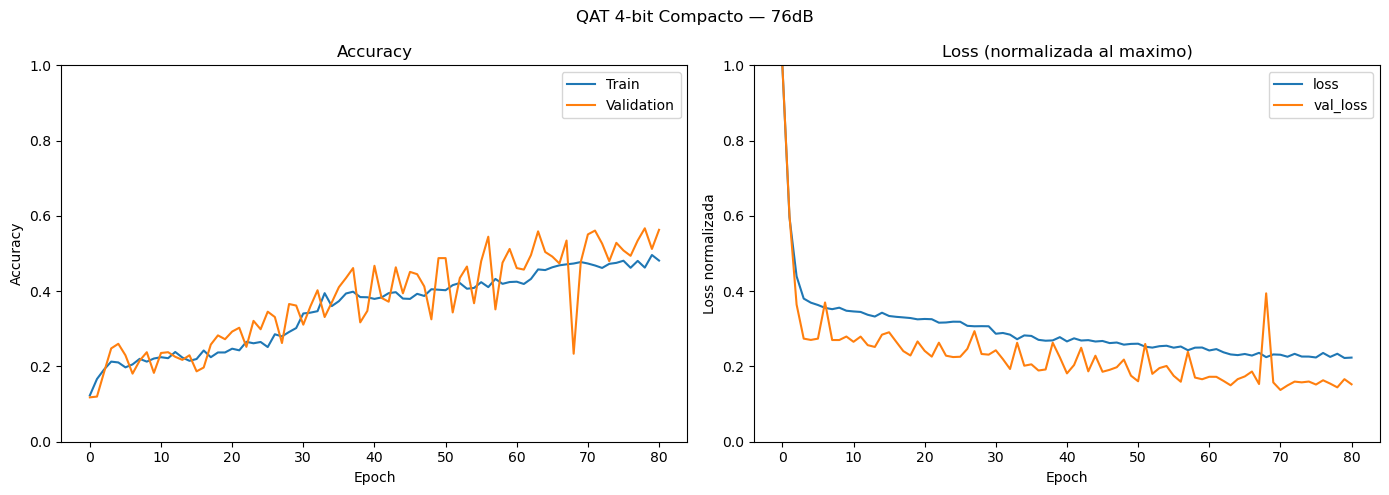


✅ Entrenamiento QAT completado.


In [ ]:
# QAT configurations

QAT_CONFIGS = [
    (16, 6, 6, 30,  1e-5),   # 16-bit: fine-tuning suave desde float
    ( 8, 4, 4, 40,  1e-4),   # 8-bit:  paso min ~0.0625, LR 1e-4 → ~62 épocas/step
    ( 4, 2, 3, 500, 5e-4),   # 4-bit:  paso min ~0.25,   LR 5e-4 → ~50 épocas/step
                             #          int_bits_act=3 para rango de activación [0, 7.5]
]

qat_models = {}

for bits, int_bits_k, int_bits_a, ft_epochs, ft_lr in QAT_CONFIGS:
    label     = f'{bits}bit'
    ckpt_dir  = f'./ckpt_compact_QAT_{label}_{TARGET_SNR}'
    best_path = f'{ckpt_dir}/compact_QAT_{label}_best.h5'
    hist_path = f'{ckpt_dir}/compact_QAT_{label}_history.json'
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f'  QAT {bits}-bit  '
          f'(int_k={int_bits_k}, int_act={int_bits_a}, LR={ft_lr})')
    print(f"{'='*60}")

    if os.path.exists(best_path):
        print(f'  Pre-trained model found: {best_path}')
        model_q = tf.keras.models.load_model(
            best_path, custom_objects=QKERAS_CO
        )
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print('  Building QAT model and transferring float weights...')
        model_q = build_compact_qat_model(
            MFCC_input_shape, NUM_CLASSES, bits, int_bits_k, int_bits_a
        )
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        transfer_float_weights(model_compact_float, model_q)

        fresh_early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=max(10, PATIENCE // 2),
            restore_best_weights=True,
            verbose=1
        )

        hist_q = model_q.fit(
            MFCC_dataset_train_batches,
            epochs=ft_epochs,
            validation_data=MFCC_dataset_validation_batches,
            callbacks=[fresh_early_stopping]
        )

        model_q.save(best_path, save_format='h5')
        print(f'  Model saved → {best_path}')
        save_history(hist_q, hist_path)

    if os.path.exists(hist_path):
        plot_training_history(
            load_history(hist_path),
            title=f'QAT {bits}-bit Compact — {TARGET_SNR}'
        )

    qat_models[bits] = model_q

print('\n QAT complete!')


## Model evaluation

In [ ]:
all_results = []

# Base float model
loss, acc = model_compact_float.evaluate(
    MFCC_dataset_validation_batches, verbose=0
)
all_results.append({'model': 'Float 32-bit', 'accuracy': acc, 'loss': loss})

# QAT models
for bits in [16, 8, 4]:
    if bits not in qat_models:
        continue
    loss, acc = qat_models[bits].evaluate(
        MFCC_dataset_validation_batches, verbose=0
    )
    all_results.append({
        'model': f'QAT {bits}-bit', 'accuracy': acc, 'loss': loss
    })

print('\n' + '=' * 52)
print(f'{"Model":<20} {"Accuracy":>12} {"Loss":>10}')
print('=' * 52)
for r in all_results:
    print(f"{r['model']:<20} {r['accuracy']:>12.4f} {r['loss']:>10.4f}")
print('=' * 52)



Modelo                   Accuracy       Loss
Float 32-bit               0.9167     0.3138
QAT 16-bit                 0.9126     0.3166
QAT 8-bit                  0.8089     0.6298
QAT 4-bit                  0.5508     1.1666

Nota: El modelo compacto tiene menos parámetros que el original.
Si el accuracy baja demasiado, se puede escalar a Conv(16→32→32)
manteniendo los mismos pool sizes y el límite de 4096 elementos.


## hls4ml: Configuracion Latency + Sintesis

Con la arquitectura BRAM-Opt v2, **todas las capas tienen <= 576 elementos**,
lo que permite usar `Strategy='Latency'` con `ReuseFactor=1`.

### Comparacion de arquitecturas

| Arquitectura | Capa mayor | Elementos | BRAM_18K est. | DSP est. |
|---|---|---|---|---|
| Original | `Dense(128)` | 2 867 200 | 681 FAIL | 932 OK |
| Compacta v1 (20x282) | `Dense(32)` | 3 584 | 681 FAIL | 928 OK |
| **BRAM-Opt v2 (20x64)** | **`Conv2D(8)`** | **576** | **~120 OK** | **~848 OK** |

El cuello de botella era la profundidad de los FIFOs `io_stream`:
`FIFO depth = N_MFCC x MFCC_FRAMES = 20 x 282 = 5640`.
Con 64 frames queda en `20 x 64 = 1280`, reduciendo los BRAMs ~5.7x.


In [ ]:
def get_hls_config_compact(keras_model, is_qat=False):
    """
    hls4ml configuration for BRAM-Opt v2 CNN with io_stream.

    KV260 (xck26-sfvc784-2LV-c / ZU5EV):
      BRAM_18K :   288  (144 RAMB36 x 2)
      DSP48E2  : 1,248  (target <= 1,200 conservative)
      CLB LUT  : 117,120
      FF (Reg) : 234,240

    All layers have <= 576 params -> Strategy='Latency' available.

    ReuseFactor per layer (BRAM-Opt v2 architecture, input 20x64):
        conv1 ( 144 MACs): RF=1  ->  144 DSPs
        conv2 ( 576 MACs): RF=4  ->  144 DSPs
        conv3 ( 576 MACs): RF=4  ->  144 DSPs
        dense1( 256 MACs): RF=1  ->  256 DSPs
        output( 160 MACs): RF=1  ->  160 DSPs
        ------------------------------------------
        Estimated total    :        848 DSPs  (68% of 1,248) OK
    """
    config = hls4ml.utils.config_from_keras_model(
        keras_model, granularity='name'
    )
    config['Model']['Strategy']    = 'Latency'
    config['Model']['ReuseFactor'] = 1

    layer_rf = {
        'conv1':  1,    # 144 MACs / 1 = 144 DSPs
        'conv2':  4,    # 576 MACs / 4 = 144 DSPs
        'conv3':  4,    # 576 MACs / 4 = 144 DSPs
        'dense1': 1,    # 256 MACs / 1 = 256 DSPs
        'output': 1,    # 160 MACs / 1 = 160 DSPs
    }
    for lname, rf in layer_rf.items():
        if lname in config.get('LayerName', {}):
            config['LayerName'][lname]['ReuseFactor'] = rf
            config['LayerName'][lname]['Strategy']    = 'Latency'
    return config


def synthesize_compact_model(keras_model, output_dir, label, is_qat=False):
    print(f"\n{'--'*30}")
    print(f'  Synthesizing : {label}')
    print(f'  Directory    : {output_dir}')
    print(f"{'--'*30}")
    config    = get_hls_config_compact(keras_model, is_qat=is_qat)
    hls_model = hls4ml.converters.convert_from_keras_model(
        keras_model,
        hls_config   = config,
        output_dir   = output_dir,
        backend      = 'Vitis',
        part         = FPGA_PART,
        clock_period = CLOCK_PERIOD,
        io_type      = 'io_stream',   # MANDATORY for CNNs
    )
    hls_model.compile()   
    hls_model.build(csim=False, synth=True, cosim=False, export=True)
    print(f'  [OK] Synthesizing completed: {label}')
    return hls_model


def parse_synth_report(output_dir, label):
    """
    Extract latency, timing/Fmax, and resources from the csynth report of Vitis HLS 2023.x.

    Real report format (columns in utilization table):
      | Name | BRAM_18K | DSP | FF | LUT | URAM |
    """
    import re
    rpt = {'model': label}
    candidates = [
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'myproject_csynth.rpt'),
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'csynth.rpt'),
    ]
    rpt_path = next((p for p in candidates if os.path.exists(p)), None)
    if rpt_path is None:
        return rpt
    content = open(rpt_path).read()

    # -- Timing ---------------------------------------------------------------
    m = re.search(
        r'\|ap_clk\s*\|\s*([\d.]+)\s*ns\s*\|\s*([\d.]+)\s*ns\s*\|\s*([\d.]+)\s*ns\s*\|',
        content
    )
    if m:
        target_ns, estimate_ns = float(m.group(1)), float(m.group(2))
        rpt['clk_target_ns']   = target_ns
        rpt['clk_estimate_ns'] = estimate_ns
        rpt['fmax_mhz']        = round(1000.0 / estimate_ns, 1)
        rpt['timing_met']      = estimate_ns < target_ns

    # -- Latency -------------------------------------------------------------
    lat_start    = content.find('+ Latency:')
    detail_start = content.find('+ Detail:', lat_start)
    if lat_start >= 0:
        lat_region = content[lat_start : detail_start] if detail_start > lat_start \
                     else content[lat_start : lat_start + 1500]
        m = re.search(
            r'\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*([\d.]+)\s*us\s*\|\s*([\d.]+)\s*us\s*\|',
            lat_region
        )
        if m:
            rpt['lat_min_cyc'] = int(m.group(1))
            rpt['lat_max_cyc'] = int(m.group(2))
            rpt['lat_min_us']  = round(float(m.group(3)), 3)
            rpt['lat_max_us']  = round(float(m.group(4)), 3)

    # -- Resources (Utilization Estimates) -------------------------------------
    def _util_row(keyword):
        pat = rf'\|{keyword}\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|'
        m = re.search(pat, content, re.IGNORECASE)
        if m:
            return [int(x) if x.strip() != '-' else None for x in m.groups()]
        return None

    _COL = ['BRAM_18K', 'DSP', 'FF', 'LUT']
    tot = _util_row('Total')
    avl = _util_row('Available')
    pct = _util_row(r'Utilization \(%\)')
    for i, res in enumerate(_COL):
        if tot and tot[i] is not None: rpt[f'{res}_used']  = tot[i]
        if avl and avl[i] is not None: rpt[f'{res}_avail'] = avl[i]
        if pct and pct[i] is not None: rpt[f'{res}_pct']   = pct[i]
    return rpt


# --- Test -----------------------------------
_test_dir = os.path.join(HLS_BASE_DIR, 'float_32')
_test_rpt  = os.path.join(_test_dir, 'myproject_prj', 'solution1',
                           'syn', 'report', 'myproject_csynth.rpt')
if os.path.exists(_test_rpt):
    _r = parse_synth_report(_test_dir, 'Float 32-bit (test)')
    print('Latencia: min={lat_min_us} us, max={lat_max_us} us'.format(**_r))
    print('Fmax:     {fmax_mhz} MHz  (estimado {clk_estimate_ns} ns)'.format(**_r))
    print('Timing met:', _r.get('timing_met'))
    print('BRAM_18K: {BRAM_18K_used}/{BRAM_18K_avail} ({BRAM_18K_pct}%)'.format(**_r))
    print('DSP:      {DSP_used}/{DSP_avail} ({DSP_pct}%)'.format(**_r))
else:
    print('Funciones definidas. Ejecutar sintesis para obtener reportes.')


Funciones definidas. Ejecutar sintesis para obtener reportes.


In [ ]:
# ─── Preview ─────────────────────────────────────

config_preview = get_hls_config_compact(model_compact_float)

print('hls4ml configuration for compact model:')
print(f"  Global Strategy: {config_preview['Model']['Strategy']}")
print(f"  io_type        : io_stream")
print('  ReuseFactor per layer:')
for lname, lcfg in config_preview.get('LayerName', {}).items():
    rf = lcfg.get('ReuseFactor', '—')
    st = lcfg.get('Strategy', '—')
    if rf != '—' or st != '—':
        print(f'    {lname:20s}: RF={rf}, Strategy={st}')

print('\nConverting model (without synthesis)...')
hls_model_preview = hls4ml.converters.convert_from_keras_model(
    model_compact_float,
    hls_config   = config_preview,
    output_dir   = './hls4ml_preview_compact',
    backend      = 'Vitis',
    part         = FPGA_PART,
    clock_period = CLOCK_PERIOD,
    io_type      = 'io_stream',
)

print('\nLayer sizes:')
verify_layer_sizes(model_compact_float)

try:
    hls4ml.utils.plot_model(
        hls_model_preview, show_shapes=True,
        show_precision=True, to_file=None
    )
except Exception as e:
    print(f'plot_model not available: {e}')


Configuración hls4ml para modelo compacto:
  Strategy global: Latency
  io_type        : io_stream
  ReuseFactor por capa:
    conv1               : RF=1, Strategy=Latency
    conv2               : RF=4, Strategy=Latency
    conv3               : RF=4, Strategy=Latency
    dense1              : RF=1, Strategy=Latency
    output              : RF=1, Strategy=Latency

Convertiendo modelo (sin síntesis)...

Verificación de tamaños de capas:

Verificacion de tamanos de capas (limite: 4096)
--------------------------------------------------------------------
  OK         conv1               :     144 elementos | shape (3, 3, 2, 8)
  OK         bn1                 :       8 elementos | shape (8,)
  OK         conv2               :     576 elementos | shape (3, 3, 8, 8)
  OK         bn2                 :       8 elementos | shape (8,)
  OK         conv3               :     576 elementos | shape (3, 3, 8, 8)
  OK         bn3                 :       8 elementos | shape (8,)
  OK         dense1 

In [ ]:
# ─── Vitis HLS synthesis ──────────────────────
# Set SYNTHESIZE = True for executing synthesis.

SYNTHESIZE = True 

if SYNTHESIZE:
    os.makedirs(HLS_BASE_DIR, exist_ok=True)
    synth_targets = [
        (model_compact_float,  'float_32',  'Float 32-bit', False),
        (qat_models.get(16),   'qat_16bit', 'QAT 16-bit',   True),
        (qat_models.get(8),    'qat_8bit',  'QAT 8-bit',    True),
        (qat_models.get(4),    'qat_4bit',  'QAT 4-bit',    True),
    ]

    hls_handles   = {}
    synth_reports = []
    for model, subdir, label, is_qat in synth_targets:
        if model is None:
            print(f'  Omitting {label} (model not available)')
            continue
        out_dir = os.path.join(HLS_BASE_DIR, subdir)
        hm = synthesize_compact_model(model, out_dir, label, is_qat=is_qat)
        hls_handles[label]   = hm
        synth_reports.append(parse_synth_report(out_dir, label))

    # Synthesis report table
    import pandas as pd
    df_rpt = pd.DataFrame(synth_reports)
    want   = ['model', 'lat_min_us', 'lat_max_us',
              'LUT_used', 'LUT_pct',
              'FF_used',  'FF_pct',
              'DSP_used', 'DSP_pct',
              'BRAM_18K_used', 'BRAM_18K_pct']
    show   = [c for c in want if c in df_rpt.columns]
    print('\nSynthesis results:')
    print(df_rpt[show].to_string(index=False))
    print(f'\nTarget: {FPGA_PART} @ {1000 // CLOCK_PERIOD} MHz')
    print('IP-XACT packages: <output_dir>/myproject_prj/solution1/impl/ip/')
else:
    print('Synthesis HLS skipped. Set SYNTHESIZE=True to execute.')

ok1
ok2
ok2
ok3
ok4
ok5

------------------------------------------------------------
  Sintetizando : Float 32-bit
  Directorio   : ./hls4ml_output_compact/float_32
------------------------------------------------------------

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2023.2 (64-bit)
  **** SW Build 4023990 on Oct 11 2023
  **** IP Build 4028589 on Sat Oct 14 00:45:43 MDT 2023
  **** SharedData Build 4025554 on Tue Oct 10 17:18:54 MDT 2023
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2023 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2023.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2023.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'chejimenez' on host 'chejimenez-Z170XP-SLI' (Linux_x86_64 version 6.17.0-19-generic) on Sun Mar 22 09:43:53 CST 2026
INFO: [HLS 200-10] On os Ubuntu 24.04.4 LTS
INFO: [HLS 200-10] In directory '/home/

## Final summary -- BRAM-Opt v2

### Architecture comparison 

| Aspecto | Original | Compacta v1 | **BRAM-Opt v2** |
|---|---|---|---|
| Input MFCC | (20, 282, 2) | (20, 282, 2) | **(20, 64, 2)** |
| hop_length | 512 (10.7 ms) | 512 (10.7 ms) | **2250 (46.9 ms)** |
| MFCC_FRAMES | 282 | 282 | **64** |
| Filtros Conv | 32->64 | 8->16->16 | **8->8->8** |
| Dense hidden | 128 | 32 | **16** |
| Max. params/capa | 2 867 200 | 3 584 | **576** OK |
| hls4ml Strategy | Resource | Resource | **Latency** OK |
| BRAM_18K est. | 681 FAIL | 681 FAIL | **~120** OK |
| DSP est. | 932 OK | 928 OK | **~848** OK |
| Parametros totales | ~1.5M | ~8K | **~2K** |
| QAT 8-bit LR | 5e-6 (estancado) | 1e-4 | **1e-4** |
| QAT 4-bit LR | 1e-6 (estancado) | 5e-4 | **5e-4** |


In [ ]:
# ─── Final table: accuracy + synthesis reports ───────────────────────────────

# ── 1. Accuracy ──────────────────────────────────────────────────────────────
print('╔' + '═'*54 + '╗')
print(f'║ {"ACCURACY / LOSS":^52} ║')
print('╠' + '═'*22 + '╦' + '═'*15 + '╦' + '═'*14 + '╣')
print(f'║ {"Model":<20} ║ {"Accuracy":>13} ║ {"Loss":>12} ║')
print('╠' + '═'*22 + '╬' + '═'*15 + '╬' + '═'*14 + '╣')
for r in all_results:
    print(f"║ {r['model']:<20} ║ {r['accuracy']:>13.4f} ║ {r['loss']:>12.4f} ║")
print('╚' + '═'*22 + '╩' + '═'*15 + '╩' + '═'*14 + '╝')

# ── 2. Synthesis reports ─────────────────────────────────────────────────────
_synth_dirs = [
    ('Float 32-bit', os.path.join(HLS_BASE_DIR, 'float_32')),
    ('QAT 16-bit',   os.path.join(HLS_BASE_DIR, 'qat_16bit')),
    ('QAT 8-bit',    os.path.join(HLS_BASE_DIR, 'qat_8bit')),
    ('QAT 4-bit',    os.path.join(HLS_BASE_DIR, 'qat_4bit')),
]
_reports = [parse_synth_report(d, lbl) for lbl, d in _synth_dirs]
_ok = [r for r in _reports if len(r) > 1]

if _ok:
    # ── Latency + Timing ────────────────────────────────────────────────────
    print()
    W = 88
    print('╔' + '═'*(W-2) + '╗')
    print(f'║ {"LATENCY AND TIMING":^{W-4}} ║')
    print('╠' + '═'*(W-2) + '╣')
    print(f'║ {"Model":<16}  {"Lat min":>9}  {"Lat max":>9}  {"Fmax":>9}  {"Clk est":>9}  {"Target":>7}  {"Timing":^8} ║')
    print(f'║ {"":16}  {"(µs)":>9}  {"(µs)":>9}  {"(MHz)":>9}  {"(ns)":>9}  {"(ns)":>7}  {"":8} ║')
    print('╠' + '═'*(W-2) + '╣')
    for r in _ok:
        lat_min = f"{r['lat_min_us']:9.3f}" if 'lat_min_us' in r else f'{"—":>9}'
        lat_max = f"{r['lat_max_us']:9.3f}" if 'lat_max_us' in r else f'{"—":>9}'
        fmax    = f"{r['fmax_mhz']:9.1f}"  if 'fmax_mhz'   in r else f'{"—":>9}'
        est     = f"{r['clk_estimate_ns']:9.3f}" if 'clk_estimate_ns' in r else f'{"—":>9}'
        tgt     = f"{r['clk_target_ns']:7.2f}"  if 'clk_target_ns'   in r else f'{"—":>7}'
        sym     = '✅ MET  ' if r.get('timing_met') else ('❌ FAIL ' if 'timing_met' in r else '—       ')
        print(f'║ {r["model"]:<16}  {lat_min}  {lat_max}  {fmax}  {est}  {tgt}  {sym} ║')
    print('╚' + '═'*(W-2) + '╝')

    # ── Resources ─────────────────────────────────────────────────────────────
    print()
    KV260 = {'LUT': 117120, 'FF': 234240, 'DSP': 1248, 'BRAM_18K': 288}
    W2 = 92
    print('╔' + '═'*(W2-2) + '╗')
    print(f'║ {"RESOURCES (Vitis HLS csynth — pre-P&R estimation)":^{W2-4}} ║')
    print('╠' + '═'*(W2-2) + '╣')
    print(f'║ {"Model":<16}  {"LUT":>9} {"LUT%":>6}  {"FF":>9} {"FF%":>5}  {"DSP":>6} {"DSP%":>6}  {"BRAM_18K":>9} {"BRAM%":>6} ║')
    print('╠' + '═'*(W2-2) + '╣')
    for r in _ok:
        lu = f"{r.get('LUT_used',  '—'):>9}";  lup = f"{r.get('LUT_pct',       '—'):>5}%"
        ff = f"{r.get('FF_used',   '—'):>9}";  ffp = f"{r.get('FF_pct',        '—'):>4}%"
        ds = f"{r.get('DSP_used',  '—'):>6}";  dsp = f"{r.get('DSP_pct',       '—'):>5}%"
        br = f"{r.get('BRAM_18K_used','—'):>9}"; brp_v = r.get('BRAM_18K_pct', 0)
        brp_str = f"{brp_v:>5}%"
        warn = ' ⚠️ ' if isinstance(brp_v, (int,float)) and brp_v > 100 else '    '
        print(f'║ {r["model"]:<16}  {lu} {lup}  {ff} {ffp}  {ds} {dsp}  {br} {brp_str}{warn}║')
    print('╠' + '═'*(W2-2) + '╣')
    print(f'║ {"KV260 available":<16}  {KV260["LUT"]:>9} {"100%":>6}  {KV260["FF"]:>9} {"100%":>5}  '
          f'{KV260["DSP"]:>6} {"100%":>6}  {KV260["BRAM_18K"]:>9} {"100%":>6}     ║')
    print('╚' + '═'*(W2-2) + '╝')

    # ── Alerta BRAM ──────────────────────────────────────────────────────────
    _bram_vals = [r.get('BRAM_18K_pct', 0) for r in _ok if 'BRAM_18K_pct' in r]
    if any(v > 100 for v in _bram_vals):
        print()
        print('⚠️ BRAM ALERT: one or more designs exceed 100% of available BRAM.')
        print('   Designs with BRAM > 100% will fail Place & Route (P&R) in Vivado.')

    print(f'\nTarget: {FPGA_PART} @ {1000//CLOCK_PERIOD} MHz')
else:
    print('⚠️  Resources not found. Execute synthesis (SYNTHESIZE=True).')

# ── 3. Layer sizes ────────────────────────────────────────────────────────
print()
print('─── Layer size verification (all must be ≤ 4096) ───')
verify_layer_sizes(model_compact_float)
total_w = sum(int(np.prod(l.get_weights()[0].shape))
              for l in model_compact_float.layers if l.get_weights())
print(f'\nTotal weight parameters: {total_w:,}')


╔══════════════════════════════════════════════════════╗
║                   ACCURACY / LOSS                    ║
╠══════════════════════╦═══════════════╦══════════════╣
║ Modelo               ║      Accuracy ║         Loss ║
╠══════════════════════╬═══════════════╬══════════════╣
║ Float 32-bit         ║        0.9167 ║       0.3138 ║
║ QAT 16-bit           ║        0.9126 ║       0.3166 ║
║ QAT 8-bit            ║        0.8089 ║       0.6298 ║
║ QAT 4-bit            ║        0.5508 ║       1.1666 ║
╚══════════════════════╩═══════════════╩══════════════╝

╔══════════════════════════════════════════════════════════════════════════════════════╗
║                                  LATENCIA Y TIMING                                   ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║ Modelo              Lat min    Lat max       Fmax    Clk est   Target   Timing  ║
║                        (µs)       (µs)      (MHz)       (ns)     (ns)           ║
╠═